# 05c – Heterogeneous ensemble: Secondary Mushroom

**Worked on by:** Andreas Schellekens (choice of the members, diversity check, averaging vs. stacking, threshold, test evaluation, deployable pipeline)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on the decisions in `01_eda.ipynb` to `05b_model_gradient_boosting.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Setup & loading

In notebook 04, PyCaret's blend of its three best models (random forest, LightGBM, extra trees) was no better than the random forest alone. All three are tree ensembles: they learn from the same splits on the same features and make the same mistakes, so averaging them changes little. An ensemble only helps when its members are wrong on **different** mushrooms. In this notebook we therefore combine models of **different families**, a *heterogeneous* ensemble, and test whether that beats the best single model.

Imports, paths and constants as in the other model notebooks. `LOKY_MAX_CPU_COUNT` silences a harmless joblib warning on Windows and must be set before scikit-learn is imported.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

DATA_DIR = Path("Data")
MODEL_DIR = Path("models")
PREPROCESSOR_PATH = MODEL_DIR / "mushroom_preprocessor.joblib"
MODEL_PATH = MODEL_DIR / "mushroom_ensemble.joblib"
MODEL_INFO_PATH = MODEL_DIR / "mushroom_ensemble.json"
METRICS_PATH = MODEL_DIR / "metrics.csv"

NOTEBOOK = "05c_model_ensemble"
RANDOM_STATE = 42
TARGET = "is_poisonous"
RECALL_TARGET = 0.90  # same target as 05a and 05b
INPUT_COLS = ["cap_diameter", "stem_height", "stem_width", "has_stem", "spore_print_color", "gill_color", "habitat",
              "season", "ring_type", "cap_shape", "stem_surface"]
CLASS_PALETTE = {"edible": "#2a9d8f", "poisonous": "#e76f51"}  # same colours as the EDA


def data_path(split, kind):
    # Files made by 02_data_preparation.ipynb, e.g. Data/validation/mushroom_cleaned_validation.csv
    return DATA_DIR / split / f"mushroom_{kind}_{split}.csv"

We load the **cleaned** files of the three sets (readable values, numerical `NaN` still empty). Every member of the ensemble is a complete pipeline that starts from these 11 columns, just like the deployable models of 03, 05a and 05b. The ensemble is then one object that the API can use in exactly the same way.

The roles of the sets are the same as in 05a and 05b: the **training set** for fitting and for cross-validation, the **validation set** to check the choices and to set the threshold, the **test set** once at the end.

In [2]:
def load_cleaned(split):
    frame = pd.read_csv(data_path(split, "cleaned"), index_col="row_id")
    return frame[INPUT_COLS], (frame["class"] == "poisonous").astype(int).rename(TARGET)


X_train, y_train = load_cleaned("train")
X_val, y_val = load_cleaned("validation")
X_test, y_test = load_cleaned("test")
print(f"Train: {X_train.shape}  |  Validation: {X_val.shape}  |  Test: {X_test.shape}")

Train: (3500, 11)  |  Validation: (750, 11)  |  Test: (750, 11)


## 2. Which members, and why?

We pick the strongest model of each family that did well so far:

| Member | Family | How it decides | Why it is in |
|---|---|---|---|
| Random forest (05a) | bagging of deep trees | average vote of 800 independent deep trees | best ranking so far |
| Gradient boosting (05b) | boosting of small trees | trees that each correct the previous ones, native missing values and categories | second best, but built in a completely different way than the forest |
| k-nearest neighbours | instance-based | share of poisonous mushrooms among the *k* most similar training mushrooms | best non-tree model in PyCaret (AUC 0.76); no trees at all |
| Logistic regression (03) | linear | weighted sum of the features | the baseline; smooth, additive effects of the strong categories, where trees work in steps |

The forest and the boosting model reuse the hyperparameters chosen in 05a and 05b (read from their saved files); KNN is tuned below; the logistic regression is the balanced baseline of notebook 03. Every member is an *unfitted* copy (`clone`), so the ensemble can train it again on exactly the rows it needs (section 4). The forest, KNN and the logistic regression get an unfitted copy of our preprocessor from notebook 02 in front of them; the boosting model has its own ordinal encoder (05b).

**Paths not taken:**
- *Extra trees* (third in PyCaret): another bagging of trees, so it would make the same mistakes as the forest. The reason PyCaret's blend did not help.
- *SVM, naive Bayes, QDA*: much weaker than KNN in PyCaret (AUC ≤ 0.67); a weak member mostly adds noise.

In [3]:
preprocessor = joblib.load(PREPROCESSOR_PATH)  # fitted in 02; clone() below gives an unfitted copy with the same settings
rf_info = json.loads((MODEL_DIR / "mushroom_random_forest.json").read_text())
print("Random forest hyperparameters (05a):", rf_info["hyperparameters"])

members = {
    "random forest": Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", RandomForestClassifier(**rf_info["hyperparameters"], random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "gradient boosting": clone(joblib.load(MODEL_DIR / "mushroom_gradient_boosting.joblib")),
    "logistic regression": Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
}

Random forest hyperparameters (05a): {'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_samples': 0.9, 'min_samples_leaf': 1, 'n_estimators': 800}


### Tuning KNN

KNN has two important settings:
- `n_neighbors` (*k*): how many similar mushrooms vote. PyCaret used the default of 5, which is very noisy with ~2% flipped labels: one wrong neighbour is 20% of the vote. Larger *k* averages over more mushrooms.
- `weights`: every neighbour counts the same (`uniform`), or closer neighbours count more (`distance`).

We try all 14 combinations with the same 5-fold cross-validation on the training set as every other search, on ROC-AUC. Similarity is measured with the Euclidean distance on the prepared features (standardised sizes, one-hot categories), which is why the preprocessor is part of the pipeline.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

knn_search = GridSearchCV(
    Pipeline([("preprocess", clone(preprocessor)), ("model", KNeighborsClassifier())]),
    {"model__n_neighbors": [5, 15, 25, 50, 75, 100, 150], "model__weights": ["uniform", "distance"]},
    scoring="roc_auc", cv=cv, n_jobs=1,
)
knn_search.fit(X_train, y_train)
members["k-nearest neighbours"] = clone(knn_search.best_estimator_)

knn_results = pd.DataFrame(knn_search.cv_results_)
print("Chosen:", knn_search.best_params_, f"– CV ROC-AUC {knn_search.best_score_:.3f}")
knn_results.pivot(index="param_model__n_neighbors", columns="param_model__weights", values="mean_test_score").round(3)

Chosen: {'model__n_neighbors': 15, 'model__weights': 'distance'} – CV ROC-AUC 0.792


param_model__weights,distance,uniform
param_model__n_neighbors,,
5,0.782,0.775
15,0.792,0.779
25,0.783,0.764
50,0.771,0.739
75,0.762,0.724
100,0.753,0.714
150,0.734,0.695


**Interpretation**
- Best: **k = 15 neighbours, weighted by distance**, CV AUC 0.792. That is clearly better than PyCaret's default KNN (k = 5, AUC 0.757 with PyCaret's own preprocessing; 0.782 with ours).
- Distance weighting is better for every *k*: the most similar mushrooms are the most informative.
- Too few neighbours (5) is noisy: a single flipped label weighs heavily. Too many (150) blurs the picture: the "neighbourhood" then contains mushrooms that are not similar at all, and the AUC drops to 0.73.

## 3. Are the members wrong on different mushrooms?

To combine members, we need their predictions on rows they have **not** been trained on: a deep forest has nearly memorised its own training rows, so its predictions there say nothing about how it behaves on new mushrooms. `cross_val_predict` gives every training mushroom a probability from a model trained on the other 4 folds: the *out-of-fold* (OOF) probabilities. We use the same 5 folds as all searches.

From these we read two things:
- the **CV ROC-AUC** of every member on its own;
- the **Spearman correlation** between the members' probabilities: 1 means two members rank the mushrooms in exactly the same order (combining them adds nothing), lower values mean they disagree on some mushrooms, which is what an ensemble needs.

This is the slowest cell of the notebook (the forest of 800 trees is trained 5 times).

In [5]:
MEMBER_ORDER = ["random forest", "gradient boosting", "k-nearest neighbours", "logistic regression"]
oof = pd.DataFrame({name: cross_val_predict(clone(members[name]), X_train, y_train, cv=cv, method="predict_proba")[:, 1]
                    for name in MEMBER_ORDER}, index=X_train.index)

print("CV ROC-AUC per member (out-of-fold):")
print(oof.apply(lambda p: roc_auc_score(y_train, p)).round(3).to_string())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(oof.corr(method="spearman"), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("Spearman correlation of the out-of-fold probabilities")
plt.show()

CV ROC-AUC per member (out-of-fold):
random forest           0.836
gradient boosting       0.821
k-nearest neighbours    0.792
logistic regression     0.698


<Figure size 550x450 with 2 Axes>

**Interpretation**
- **On its own** every member scores as before: random forest 0.836, gradient boosting 0.821, KNN 0.792, logistic regression 0.698. (The forest is 0.001 below its score in 05a: here the preprocessor is refitted inside every fold, in 05a it was fitted on all training rows beforehand. For trees this makes practically no difference.)
- **The forest and KNN rank the mushrooms almost the same way** (0.87). That makes sense: a forest is itself a kind of "adaptive nearest neighbours" method, because every leaf groups mushrooms with similar values. KNN is a weaker version of something the forest already does.
- **Forest and boosting** are also strongly correlated (0.88), but both are strong, so even a small difference can help.
- **Logistic regression is the most different member** (0.46–0.61): it sees the data in a completely different way (one weighted sum, no combinations). But it is also far weaker (AUC 0.70).

So the expectation is modest: the strong members are similar, and the member that is really different is weak. An ensemble needs members that are **both** good **and** wrong on different mushrooms.

## 4. How to combine the members: averaging or stacking?

Two ways to turn several probabilities into one:
- **Averaging** (soft voting): the mean of the members' probabilities. No extra learning. A weakness here: the members' probabilities are not on the same scale. The forest uses balanced class weights, which push its probabilities up; the boosting model has none (that is why their thresholds in 05a and 05b were so different), so a plain mean mixes two different scales.
- **Stacking**: a small second model, the *meta-learner*, learns how to combine the members. Here that is a logistic regression with the members' probabilities as its inputs: it learns one weight per member (how much to trust it) and an intercept. It is trained on the **out-of-fold** probabilities of section 3. If it were trained on predictions for rows the members had seen, it would learn to trust the forest blindly, because the forest is almost always right on its own training rows.

We compare a few combinations, together with the single members as reference:

| Combination | Question it answers |
|---|---|
| average / stack of random forest + gradient boosting | do the two tree ensembles complement each other? |
| stack of the two tree models + KNN | does a non-tree model add something? |
| average / stack of all four | does the whole heterogeneous ensemble help? |

**How we score them, without refitting anything:**
- *CV ROC-AUC*: for averaging, simply the AUC of the mean of the OOF probabilities. For stacking, the meta-learner gets its own 5-fold cross-validation on the OOF probabilities, so it is also scored on rows it was not trained on.
- *Validation*: every member is trained once on all 3500 training rows and predicts the validation set. Averaging takes the mean; stacking applies a meta-learner trained on all OOF probabilities. This is exactly what scikit-learn's `StackingClassifier` does internally (section 5 checks that). Next to the AUC we show the **precision at 90% recall** on validation: at our operating point, how many of the mushrooms called poisonous really are.

**Decision rule, fixed in advance:** the ensemble with the highest CV ROC-AUC becomes the 05c model (cross-validation over 3500 rows is the more stable estimate; the validation set checks it). Whether that ensemble is better than the best single model, and worth its extra size, is decided in `07_model_comparison.ipynb`.

In [6]:
val_members = pd.DataFrame({name: clone(members[name]).fit(X_train, y_train).predict_proba(X_val)[:, 1]
                            for name in MEMBER_ORDER}, index=X_val.index)

TREES = ["random forest", "gradient boosting"]
candidates = {name: ("single", [name]) for name in MEMBER_ORDER}
candidates.update({
    "average: forest + boosting": ("average", TREES),
    "stack: forest + boosting": ("stack", TREES),
    "stack: forest + boosting + KNN": ("stack", TREES + ["k-nearest neighbours"]),
    "average: all four": ("average", MEMBER_ORDER),
    "stack: all four": ("stack", MEMBER_ORDER),
})


def combine(method, names):
    """Out-of-fold (train) and validation probabilities of one combination."""
    if method in ("single", "average"):
        return oof[names].mean(axis=1), val_members[names].mean(axis=1)
    p_oof = cross_val_predict(LogisticRegression(), oof[names], y_train, cv=cv, method="predict_proba")[:, 1]
    meta = LogisticRegression().fit(oof[names], y_train)
    return pd.Series(p_oof, index=oof.index), pd.Series(meta.predict_proba(val_members[names])[:, 1], index=val_members.index)


def precision_at_recall(y_true, p, target=RECALL_TARGET):
    precision, recall, _ = precision_recall_curve(y_true, p)
    return precision[:-1][recall[:-1] >= target].max()


rows, val_probs = {}, {}
for name, (method, names) in candidates.items():
    p_oof, val_probs[name] = combine(method, names)
    rows[name] = {"CV ROC-AUC": roc_auc_score(y_train, p_oof), "validation ROC-AUC": roc_auc_score(y_val, val_probs[name]),
                  f"validation precision at recall {RECALL_TARGET}": precision_at_recall(y_val, val_probs[name])}
comparison = pd.DataFrame(rows).T

ensembles = [name for name, (method, _) in candidates.items() if method != "single"]
CHOSEN = comparison.loc[ensembles, "CV ROC-AUC"].idxmax()
print("Chosen ensemble (highest CV ROC-AUC):", CHOSEN)
comparison.round(4)

Chosen ensemble (highest CV ROC-AUC): stack: forest + boosting


,CV ROC-AUC,validation ROC-AUC,validation precision at recall 0.9
random forest,0.8363,0.8168,0.4613
gradient boosting,0.8206,0.8193,0.4672
k-nearest neighbours,0.7919,0.7870,0.4393
logistic regression,0.6978,0.7038,0.4213
average: forest + boosting,0.8363,0.8216,0.4622
stack: forest + boosting,0.8381,0.8206,0.4680
stack: forest + boosting + KNN,0.8379,0.8205,0.4672
average: all four,0.8287,0.8158,0.4629
stack: all four,0.8380,0.8212,0.4655


**Interpretation**
- **The best ensemble is the stack of forest + boosting:** CV AUC 0.838, against 0.836 for the forest alone; on validation 0.821, against 0.817 (forest) and 0.819 (boosting). It is the best in both, but the gains are tiny: 0.002 in cross-validation and 0.001–0.004 on validation, smaller than the fold-to-fold standard deviation (0.005).
- **KNN and the logistic regression add nothing.** A stack with KNN (0.8379) or with all four members (0.8380) scores the same as the stack of the two tree models: the meta-learner learns that they bring no information the trees don't already have.
- **Averaging all four hurts** (0.829): averaging cannot ignore a weak member, so the logistic regression pulls the average down. That is the main advantage of stacking: it *learns* the weights, and can give a weak member (almost) none.
- **Averaging forest + boosting** equals the forest in CV (0.836) and is the best on validation (0.822). The difference with the stack is within the noise; we follow the rule fixed in advance (highest CV AUC).
- **At our operating point nothing changes:** the precision at 90% recall on validation is 0.46–0.47 for both tree models and every ensemble. Catching 9 out of 10 poisonous mushrooms costs about the same number of false alarms, whichever combination we use.
- Why so little? The members agree on most mushrooms, and where they all fail, the information to recognise the mushroom is probably simply not in the data (missing values, flipped labels). `07_model_comparison.ipynb` checks this in the error analysis.

**Decision (by the rule above):** the **stack of random forest + gradient boosting**.

## 5. The final ensemble

We build the chosen combination as one scikit-learn object, so it can be saved and deployed like the other models:
- stacking → `StackingClassifier`: it trains every member on all training rows, computes the out-of-fold probabilities with the `cv` we give it (our 5 folds) and fits the logistic regression meta-learner on them;
- averaging → `VotingClassifier(voting="soft")`.

The `assert` checks that this object gives **exactly** the validation probabilities of the manual version in section 4. That proves that the comparison above measured the model we are now going to save. If the chosen ensemble is a stack, we also show the weights the meta-learner gave the members.

In [7]:
method, names = candidates[CHOSEN]
estimators = [(name.replace(" ", "_"), clone(members[name])) for name in names]
if method == "stack":
    ensemble = StackingClassifier(estimators, final_estimator=LogisticRegression(), cv=cv, stack_method="predict_proba")
else:
    ensemble = VotingClassifier(estimators, voting="soft")
ensemble.fit(X_train, y_train)

p_val = ensemble.predict_proba(X_val)[:, 1]
assert np.allclose(p_val, val_probs[CHOSEN]), "The ensemble differs from the manual combination of section 4"
print(f"{CHOSEN}: validation ROC-AUC {roc_auc_score(y_val, p_val):.4f} (identical to section 4)")

if method == "stack":
    meta = ensemble.final_estimator_
    weights = pd.Series(meta.coef_[0], index=names, name="meta-learner weight")
    print(f"Intercept: {meta.intercept_[0]:.2f}")
    display(weights.round(2).to_frame())

stack: forest + boosting: validation ROC-AUC 0.8206 (identical to section 4)
Intercept: -2.93


,meta-learner weight
random forest,4.22
gradient boosting,2.10


**Interpretation**
- The meta-learner computes `score = −2.93 + 4.22 × p(forest) + 2.10 × p(boosting)` and turns that score into a probability with the logistic function. Both members get a clearly positive weight, so both are used, and the forest gets about twice the weight of the boosting model.
- The weights are not a pure measure of "trust": the members' probabilities are on different scales (the forest's are pushed up by its class weights). The meta-learner corrects for that as well, which is exactly what plain averaging cannot do.

## 6. Choosing the decision threshold

Exactly as in 05a and 05b: the ensemble, trained on the training rows, predicts the validation set, and we take the **highest threshold that still catches 90% of the poisonous validation mushrooms**. The test set stays untouched.

In [8]:
def threshold_for_recall(y_true, p, target):
    # Highest threshold whose recall is still >= target (recall only drops when the threshold rises)
    _, recall, thresholds = precision_recall_curve(y_true, p)
    return thresholds[recall[:-1] >= target].max()


def operating_point(y_true, p, threshold):
    pred = p >= threshold
    return {"threshold": threshold, "recall": recall_score(y_true, pred), "precision": precision_score(y_true, pred),
            "share_of_edible_flagged": (pred & (y_true == 0)).sum() / (y_true == 0).sum()}


threshold = threshold_for_recall(y_val, p_val, RECALL_TARGET)
pd.DataFrame({"default threshold 0.5": operating_point(y_val, p_val, 0.5),
              f"recall >= {RECALL_TARGET:.2f}": operating_point(y_val, p_val, threshold)}).T.round(3)

,threshold,recall,precision,share_of_edible_flagged
default threshold 0.5,0.50,0.669,0.776,0.118
recall >= 0.90,0.13,0.901,0.468,0.624


**Interpretation**
- The threshold for 90% recall is **0.13**. At that point precision is 0.47 and 62% of the edible validation mushrooms are flagged: the same operating point as the forest (0.46 / 64%) and the boosting model (0.47 / 63%).
- At 0.5 the ensemble catches more poisonous mushrooms (67%) than either member (63%), but that is only a different probability scale: what counts is the trade-off at the threshold we actually use.

## 7. Validation & test evaluation

The ensemble is final. We evaluate it **once** on the test set, at threshold 0.5 and at the chosen threshold, with the same `evaluate` helper as notebooks 03–05b. The validation rows are listed too, for the model choice in `07_model_comparison.ipynb`.

In [9]:
def evaluate(name, split, y_true, p_poisonous, threshold=0.5):
    y_pred = (p_poisonous >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "notebook": NOTEBOOK,
        "split": split,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "recall_poisonous": recall_score(y_true, y_pred),
        "precision_poisonous": precision_score(y_true, y_pred, zero_division=0),
        "f1_poisonous": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, p_poisonous),
        "missed_poisonous": fn,
        "false_alarms": fp,
    }


p_test = ensemble.predict_proba(X_test)[:, 1]
model_name = f"ensemble ({CHOSEN})"
results = []
for split, y_split, p_split in [("validation", y_val, p_val), ("test", y_test, p_test)]:
    results.append(evaluate(model_name, split, y_split, p_split, threshold=0.5))
    results.append(evaluate(f"{model_name}, recall {RECALL_TARGET:.2f}", split, y_split, p_split, threshold=threshold))
pd.DataFrame(results).set_index(["model", "split"]).drop(columns="notebook").round(3)

,,threshold,accuracy,recall_poisonous,precision_poisonous,f1_poisonous,roc_auc,missed_poisonous,false_alarms
model,split,,,,,,,,
ensemble (stack: forest + boosting),validation,0.50,0.801,0.669,0.776,0.718,0.821,94,55
"ensemble (stack: forest + boosting), recall 0.90",validation,0.13,0.575,0.901,0.468,0.616,0.821,28,291
ensemble (stack: forest + boosting),test,0.50,0.811,0.662,0.803,0.726,0.851,96,46
"ensemble (stack: forest + boosting), recall 0.90",test,0.13,0.581,0.923,0.473,0.625,0.851,22,292


The confusion matrices on the test set at both thresholds; the bottom-left cell counts the poisonous mushrooms called edible.

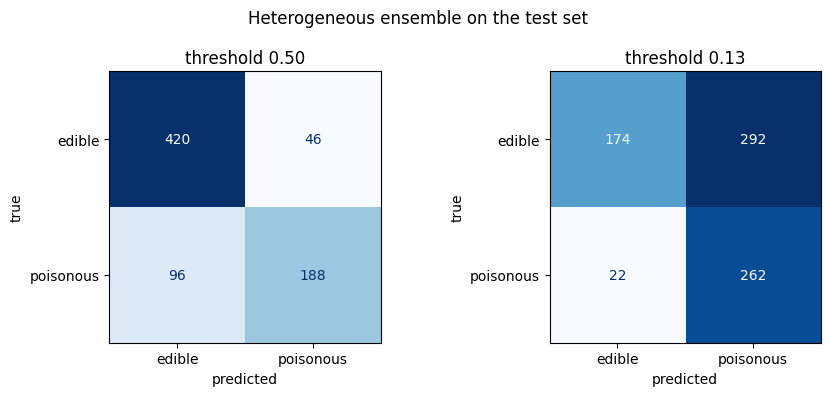

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, t in zip(axes, [0.5, threshold]):
    ConfusionMatrixDisplay.from_predictions(y_test, (p_test >= t).astype(int), display_labels=["edible", "poisonous"],
                                            cmap="Blues", colorbar=False, ax=ax)
    ax.set(title=f"threshold {t:.2f}", xlabel="predicted", ylabel="true")
    ax.grid(False)
fig.suptitle("Heterogeneous ensemble on the test set")
plt.tight_layout()
plt.show()

**Interpretation**
- **At threshold 0.5:** test AUC 0.851, accuracy 0.811, recall 0.66 (96 missed, 46 false alarms).
- **At threshold 0.13:** recall **0.923** (262 of 284 poisonous mushrooms caught, **22 missed**), 292 false alarms, precision 0.47. The forest (20 missed / 296 false alarms) and the boosting model (17 / 301) are at the same point: the differences are a few mushrooms either way.
- The test AUC (0.851) is the highest of the three (forest 0.842, boosting 0.847), in line with the ensemble being the best on CV and validation as well. But the differences are well within the uncertainty of 750 test rows; `07_model_comparison.ipynb` tests them with a paired bootstrap.

## 8. Saving the model for deployment

The ensemble is one scikit-learn object that takes the 11 cleaned columns and returns `predict_proba`, so the API can use it exactly like the other models: apply the cleaning of notebook 02 (sections 2–5), call `predict_proba`, and compare the probability with the threshold in the JSON file. It contains the 800-tree forest, so the file is large: like the forest of 05a it is not committed to git (`.gitignore`) and must be rebuilt by this notebook or the retraining pipeline; the JSON file with the threshold is committed.

In [11]:
joblib.dump(ensemble, MODEL_PATH, compress=3)
model_info = {
    "model": model_name,
    "notebook": NOTEBOOK,
    "method": method,
    "members": names,
    "threshold": round(float(threshold), 4),
    "threshold_rule": f"highest threshold with recall (poisonous) >= {RECALL_TARGET} on the validation set",
    "cv_roc_auc": round(float(comparison.loc[CHOSEN, "CV ROC-AUC"]), 4),
    "validation_roc_auc": round(float(roc_auc_score(y_val, p_val)), 4),
    "knn_hyperparameters": {k.removeprefix("model__"): v for k, v in knn_search.best_params_.items()},
    "input_columns": INPUT_COLS,
}
if method == "stack":
    model_info["meta_learner"] = {"intercept": round(float(meta.intercept_[0]), 4),
                                  "weights": {name: round(float(w), 4) for name, w in weights.items()}}
MODEL_INFO_PATH.write_text(json.dumps(model_info, indent=2))
print(f"Saved {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1e6:.1f} MB)  and  {MODEL_INFO_PATH}")
print(json.dumps(model_info, indent=2))

Saved models\mushroom_ensemble.joblib  (27.4 MB)  and  models\mushroom_ensemble.json
{
  "model": "ensemble (stack: forest + boosting)",
  "notebook": "05c_model_ensemble",
  "method": "stack",
  "members": [
    "random forest",
    "gradient boosting"
  ],
  "threshold": 0.1298,
  "threshold_rule": "highest threshold with recall (poisonous) >= 0.9 on the validation set",
  "cv_roc_auc": 0.8381,
  "validation_roc_auc": 0.8206,
  "knn_hyperparameters": {
    "n_neighbors": 15,
    "weights": "distance"
  },
  "input_columns": [
    "cap_diameter",
    "stem_height",
    "stem_width",
    "has_stem",
    "spore_print_color",
    "gill_color",
    "habitat",
    "season",
    "ring_type",
    "cap_shape",
    "stem_surface"
  ],
  "meta_learner": {
    "intercept": -2.9278,
    "weights": {
      "random forest": 4.2244,
      "gradient boosting": 2.102
    }
  }
}


## 9. Storing the metrics

Both test rows and both validation rows go into the shared `models/metrics.csv`; rows of this notebook are replaced when it is run again.

In [12]:
new_rows = pd.DataFrame(results)
if METRICS_PATH.exists():
    metrics = pd.read_csv(METRICS_PATH)
    metrics = pd.concat([metrics[metrics["notebook"] != NOTEBOOK], new_rows], ignore_index=True)
else:
    metrics = new_rows
metrics.to_csv(METRICS_PATH, index=False)
metrics.round(3)

,model,notebook,split,threshold,accuracy,recall_poisonous,precision_poisonous,f1_poisonous,roc_auc,missed_poisonous,false_alarms
0,naive (always edible),03_model_baseline,validation,0.500,0.621,0.000,0.000,0.000,0.500,284,0
1,logistic regression (balanced),03_model_baseline,validation,0.500,0.656,0.623,0.540,0.578,0.704,107,151
2,naive (always edible),03_model_baseline,test,0.500,0.621,0.000,0.000,0.000,0.500,284,0
3,logistic regression (balanced),03_model_baseline,test,0.500,0.677,0.630,0.566,0.597,0.711,105,137
4,PyCaret random forest (default),04_model_automl,validation,0.500,0.803,0.648,0.793,0.713,0.818,100,48
5,PyCaret random forest (default),04_model_automl,test,0.500,0.785,0.606,0.778,0.681,0.838,112,49
6,random forest (tuned),05a_model_random_forest,validation,0.500,0.800,0.634,0.796,0.706,0.817,104,46
7,"random forest (tuned, recall 0.90)",05a_model_random_forest,validation,0.161,0.564,0.901,0.461,0.610,0.817,28,299
8,random forest (tuned),05a_model_random_forest,test,0.500,0.795,0.613,0.798,0.693,0.842,110,44
9,"random forest (tuned, recall 0.90)",05a_model_random_forest,test,0.161,0.579,0.930,0.471,0.626,0.842,20,296


## 10. Conclusion

- **A heterogeneous ensemble needs members that are both strong and different.** Here the strong members (forest, boosting, and KNN as a weaker copy of the forest) are similar, and the member that is really different (logistic regression) is weak. The diversity check of section 3 predicted this before we combined anything.
- **The best combination is a stack of forest + boosting** with a logistic regression meta-learner: CV AUC 0.838, validation 0.821, test 0.851, the highest of all models on all three. The gain over the best single model is small (0.002–0.004 AUC on CV and validation), and at our operating point (90% recall) it catches and misses about the same mushrooms (22 missed, 292 false alarms on the test set).
- **Stacking beats averaging** when the members differ in quality or probability scale: it learns the weights and can ignore a weak member, where averaging all four made things worse.
- **The cost:** the ensemble contains both models (27.4 MB, mostly the forest) and takes the time of both for every prediction.
- **Deployable:** `models/mushroom_ensemble.joblib` (not in git, rebuilt by this notebook) with `models/mushroom_ensemble.json` (threshold 0.130, members, meta-learner weights). Same input and use as the other models.

**Next step:** `07_model_comparison.ipynb` compares all models on the same rows and decides whether this small gain is worth the extra size.